# LightGBM Sybil Detector — LayerZero

LightGBM, 3-seed ensemble (seeds 42, 123, 456), 5,000-round ceiling with early stopping (50 rounds) on
validation log-loss, on the stratified group split. Fixed settings (`sp.lgbm_model`): `subsample_freq=1`
(required for bagging), `colsample_bytree=0.8`, and `force_col_wise` / `deterministic` so the trees are the
same on every run. `num_leaves`, `learning_rate`, `subsample` and `reg_lambda` are tuned.

Training, evaluation and helper code live in `sybil_pipeline.py` (`sp.fit_lgbm`, `sp.evaluate`), the same
code `11_split_comparison` runs on the original random split.

**Results**: test metrics in section 3, saved to `results/04_lightgbm_sybil.json`.

## Setup

In [1]:
import warnings
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

DATA_DIR = './data'
FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)

## 1. Data and split

Stratified group split on gas provision trees (49 % train, 21 % validation, 30 % test); the Sybil class is
upsampled to 1:1 in the training partition only.

In [2]:
# ── Feature table (steps 1-7; see 00_data_pipeline) and the stratified group split ──
df, _, _ = sp.build_master_df(DATA_DIR)
S = sp.make_splits(df, FEATS, method='group', seed=sp.SEED)   # asserts no gas provision tree spans two partitions
print(sp.split_summary(df, S).to_string(index=False))
print(f"Train after upsampling: {len(S['X_train']):,} rows ({S['y_train'].mean()*100:.1f}% Sybil)\n")
leak = sp.leakage_report(df, S)

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, gas provision trees (371,764 trees)


All 62 features present ✓  (47.7s)


     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130435   5463    124972      4.19
Train after upsampling: 408,244 rows (50.0% Sybil)



Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a gas provision tree with a train address: 0 / 130,435
Test Sybils sharing a gas provision tree with a train Sybil:     0 / 5,463


## 2. Train (3 seeds, early stopping on validation)

Hyperparameters selected on validation by `02_hyperparameter_search`.

In [3]:
XGB_SELECTED, LGBM_SELECTED = sp.load_selected_params()
PARAMS = LGBM_SELECTED
print('Tuned hyperparameters:', PARAMS)
m = sp.fit_lgbm(S, PARAMS)

Tuned hyperparameters: {'num_leaves': 127, 'learning_rate': 0.05, 'subsample': 0.7, 'reg_lambda': 1.0}


  LightGBM seed=42  rounds=1277  56.1s


  LightGBM seed=123  rounds=1248  54.9s


  LightGBM seed=456  rounds=1143  49.9s


## 3. Evaluate on the test set

Threshold: the F1-maximizing threshold on validation.

  Threshold : 0.6001
  Precision : 0.7267
  Recall    : 0.7111
  F1        : 0.7188
  AUROC     : 0.9683
  Avg Prec  : 0.7696
  Brier     : 0.0194


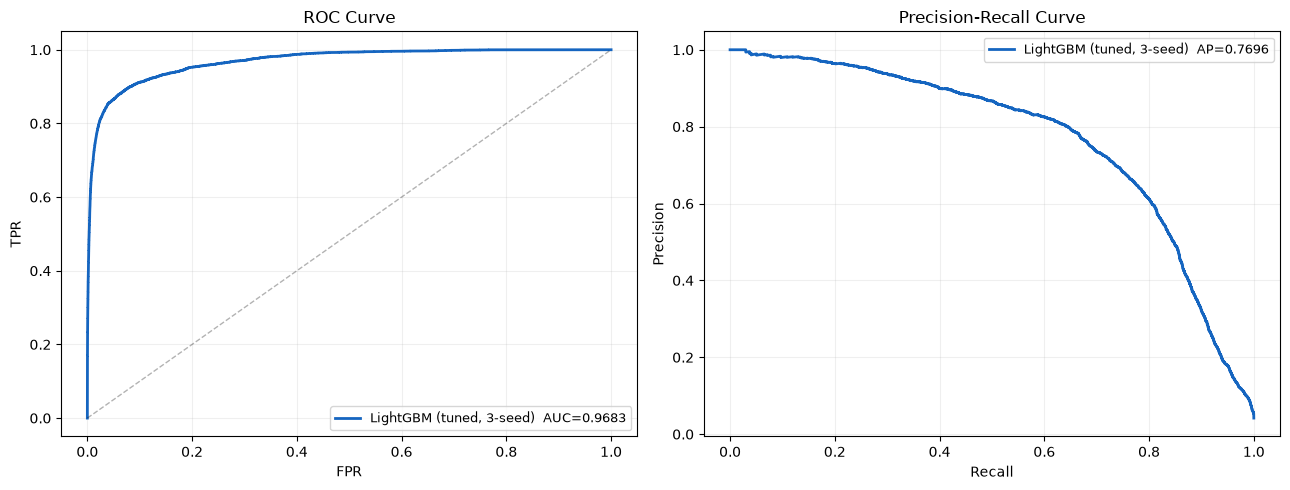

In [4]:
res = sp.evaluate('LightGBM (tuned, 3-seed)', S['y_val'], m['val'], S['y_test'], m['test'])
sp.print_metrics(res)
sp.plot_curves([res])

## 4. Feature importances

Total gain: the reduction in training loss summed over every split on the feature, normalized to sum to 1
for each model and averaged over the three seeds (`sp.gain_importance`). Gain credits correlated features
unevenly; `09_shap_importance` reports SHAP values and sums them by feature family.

Top 20 features (normalized total gain, mean over 3 seeds):
                          Feature  NormGain
                  l0_tx_time_span  0.185950
              num_transactions_in  0.069874
            n_l0_source_contracts  0.060700
             l0_avg_stargate_swap  0.059386
              earliest_l0_tx_time  0.054005
               n_l0_source_chains  0.051557
             earliest_tx_block_in  0.046186
                latest_l0_tx_time  0.045518
                 max_tx_value_out  0.044335
       gas_provision_block_number  0.036089
           tx_value_per_block_out  0.034025
                     time_span_in  0.029807
                  min_tx_value_in  0.025031
    n_l0_project_per_source_chain  0.023843
                    n_l0_projects  0.015835
provider_min_gas_provision_amount  0.013737
                 min_tx_value_out  0.013198
               n_eth_interactions  0.012913
provider_avg_gas_provision_amount  0.012523
                 provider_fan_out  0.012073


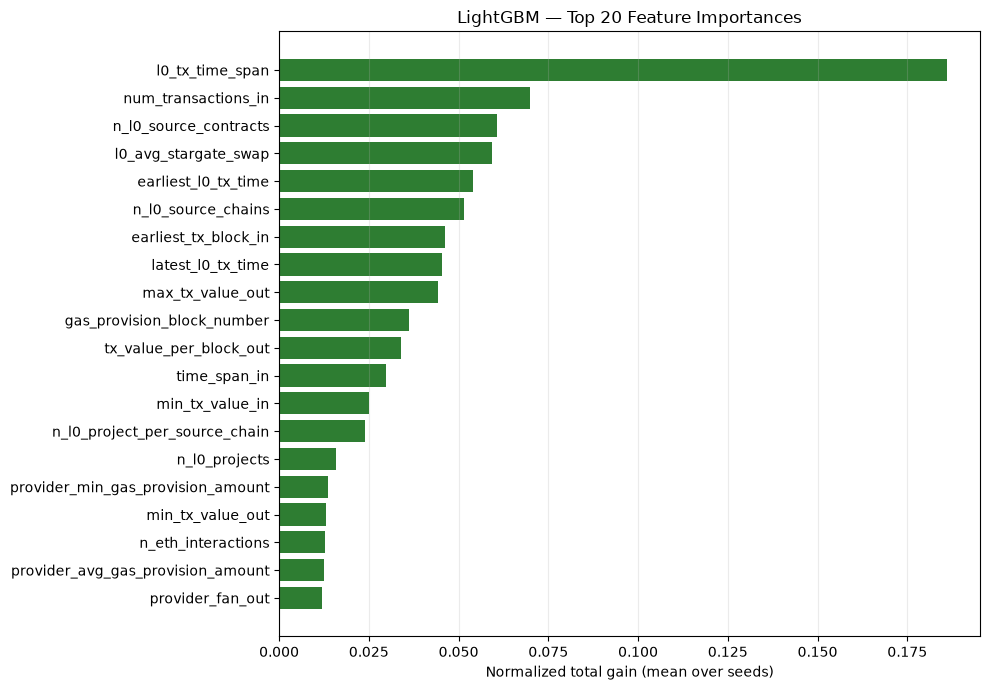

In [5]:
imp_df = sp.gain_importance(m['models'], FEATS)
print('Top 20 features (normalized total gain, mean over 3 seeds):')
print(imp_df.head(20).to_string(index=False))
sp.plot_importance(imp_df, 'LightGBM — Top 20 Feature Importances', '#2E7D32')

## 5. Operating points

Precision, recall and counts on the test set at fixed thresholds and at the threshold chosen on validation
(whose row equals the reported test metrics).

In [6]:
print(sp.operating_points(S['y_test'], m['test'], res['threshold']).round(4).to_string(index=False))

 threshold  precision  recall     f1  flagged  false_pos                 note
    0.9500     0.8752  0.4800 0.6199     2996        374                     
    0.9000     0.8408  0.5609 0.6729     3644        580                     
    0.8500     0.8199  0.6110 0.7002     4071        733                     
    0.8000     0.8016  0.6407 0.7122     4366        866                     
    0.7500     0.7817  0.6654 0.7189     4650       1015                     
    0.7000     0.7605  0.6819 0.7190     4898       1173                     
    0.6001     0.7267  0.7111 0.7188     5346       1461 validation threshold
    0.5000     0.6957  0.7395 0.7169     5807       1767                     


## Save results

Scalar metrics go to `results/04_lightgbm_sybil.json` with the code commit, so every number in the paper can be traced
to one run. Validation and test probabilities go to `output/` for `06_cross_ensemble_sybil` and `10_tie_out`.

In [7]:
sp.save_results([res], '04_lightgbm_sybil', leakage=leak,
                extra=dict(params=PARAMS, rounds=m['rounds'],
                           importance=imp_df.set_index('Feature')['NormGain'].to_dict()))
sp.save_predictions(df, S, '04_lightgbm_sybil', prob_lgbm=m)

Saved results/04_lightgbm_sybil.json


Saved output/pred_04_lightgbm_sybil_val.parquet (91,305 rows)
Saved output/pred_04_lightgbm_sybil_test.parquet (130,435 rows)
